In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
285,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
286,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
287,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0


In [ ]:
df.shape

(289, 14)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


In [ ]:
target_col = df.columns[-1]
print(f"\n--- Step 7: Class Distribution (Column: {target_col}) ---")
print(df[target_col].value_counts())


--- Step 7: Class Distribution (Column: output) ---
output
1    165
0    124
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
print('First 5 rows of feature set (X):')
display(X.head())

print('\nFirst 5 rows of target variable (y):')
display(y.head())

First 5 rows of feature set (X):


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2



First 5 rows of target variable (y):


,output
0,1
1,1
2,1
3,1
4,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Number of training records: {len(X_train)}")

Number of training records: 231


In [ ]:
print(f"Number of testing records: {len(X_test)}")

Number of testing records: 58


In [ ]:
model = RandomForestClassifier(
  n_estimators=100,
  random_state=42
  )

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8448
Accuracy: 84.48%


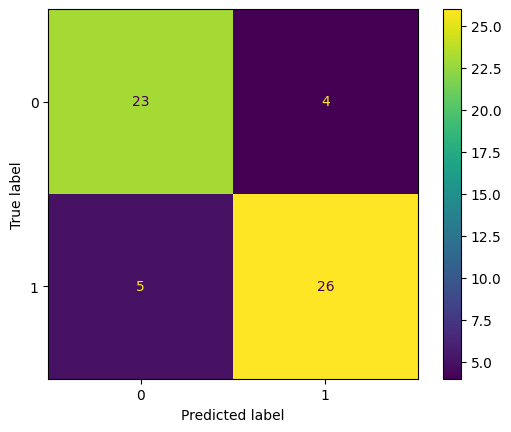

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        27
           1       0.87      0.84      0.85        31

    accuracy                           0.84        58
   macro avg       0.84      0.85      0.84        58
weighted avg       0.85      0.84      0.84        58



In [ ]:
n_estimators_list = [10, 50, 100, 200]

for n_estimators in n_estimators_list:
    print(f"\n--- Training Random Forest with {n_estimators} trees ---")
    model_n = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    model_n.fit(X_train, y_train)
    y_pred_n = model_n.predict(X_test)
    accuracy_n = accuracy_score(y_test, y_pred_n)
    print(f"Accuracy with {n_estimators} trees: {accuracy_n:.4f}")


--- Training Random Forest with 10 trees ---
Accuracy with 10 trees: 0.8448

--- Training Random Forest with 50 trees ---
Accuracy with 50 trees: 0.8103

--- Training Random Forest with 100 trees ---
Accuracy with 100 trees: 0.8448

--- Training Random Forest with 200 trees ---
Accuracy with 200 trees: 0.8448
